1. Import Libraries

In [6]:
import numpy as np # Linear Algebra
import pandas as pd # Data Processing, csv file (example pd.read_csv)
import matplotlib.pyplot as plt # Data Visualization
import seaborn as sns # Data Visualization

3. Read & Load Data Base

In [14]:
train = pd.read_csv('/content/drive/MyDrive/train.csv')
test = pd.read_csv('/content/drive/MyDrive/test.csv')

4. Train

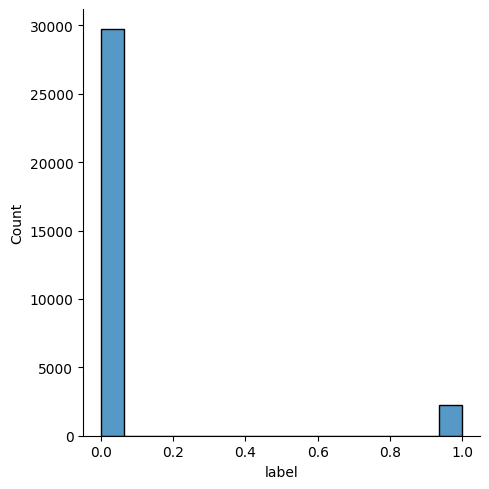

In [15]:
sns.displot(train['label'])

In [16]:
label = train['label']

In [17]:
train.drop(['label'], axis=1, inplace=True)
train

,id,tweet
0,1,@user when a father is dysfunctional and is s...
1,2,@user @user thanks for #lyft credit i can't us...
2,3,bihday your majesty
3,4,#model i love u take with u all the time in ...
4,5,factsguide: society now #motivation
...,...,...
31957,31958,ate @user isz that youuu?ðððððð...
31958,31959,to see nina turner on the airwaves trying to...
31959,31960,listening to sad songs on a monday morning otw...
31960,31961,"@user #sikh #temple vandalised in in #calgary,..."


Combine Train and Test

In [20]:
combi = pd.concat([train, test])
combi

,id,tweet
0,1,@user when a father is dysfunctional and is s...
1,2,@user @user thanks for #lyft credit i can't us...
2,3,bihday your majesty
3,4,#model i love u take with u all the time in ...
4,5,factsguide: society now #motivation
...,...,...
17192,49155,thought factory: left-right polarisation! #tru...
17193,49156,feeling like a mermaid ð #hairflip #neverre...
17194,49157,#hillary #campaigned today in #ohio((omg)) &am...
17195,49158,"happy, at work conference: right mindset leads..."


Clean tweets

In [21]:
tweets = train['tweet']

count_words = tweets.str.findall(r'(\w+)').str.len()
print(count_words.sum())

443676


In [22]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords') # Download the stopwords resource

""" Cleaning Tweets """
tweets = tweets.str.lower()

# removing special chatacters and numbers
tweets = tweets.apply(lambda x : re.sub(r"[^a-z\s]", "", x)) # Use raw string for regex

# remove hash tags
tweets = tweets.str.replace("#", " ")

#remove words less than 2 character
tweets = tweets.apply(lambda x: ' '.join([w for w in x.split() if len(w)>2]))

# removing stopwords
stopwords = set(stopwords.words("english"))
tweets = tweets.apply(lambda x : " ".join(word for word in x.split() if word not in stopwords)) # Corrected typo: xspli() to x.split()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Remove freqeuntly used words

In [23]:
most_freq_words = pd.Series(' '.join(tweets).lower().split()).value_counts()[:25]
tweets = tweets.apply(lambda x : " ".join(word for word in x.split() if word not in most_freq_words))
print(most_freq_words)

count_words = tweets.str.findall(r'(\w+)').str.len()
print(count_words.sum())

user        17495
love         2726
day          2287
happy        1691
amp          1607
life         1126
time         1126
like         1053
today        1007
new           988
positive      934
thankful      925
get           919
people        865
bihday        854
good          850
cant          813
one           783
see           758
dont          736
fathers       726
smile         715
want          646
take          622
work          617
Name: count, dtype: int64
213935


Remove rare words

In [24]:
from collections import Counter
from itertools import chain

# split words into lists
v = tweets.str.split().tolist()
# compute global word frequency
c = Counter(chain.from_iterable(v))
# filter, join and re-assign
tweets = [' '.join([j for j in i if c[j] > 1]) for i in v]

total_word = 0
for x,word in enumerate(tweets):
    num_word = len(word.split())
    #print(num_word)
    total_word =  total_word + num_word
print(total_word)


189225


Create tokins with Spacey

In [28]:
# Upgrade pip and setuptools
!pip install --upgrade pip setuptools wheel

# Install the latest compatible spaCy version for the current Python environment
!pip install spacy spacy-lookups-data

# NOTE: After installing, you might need to restart the Colab runtime (Runtime > Restart runtime) for changes to take full effect.
import spacy
import spacy.cli

# Attempt to download and load 'en_core_web_lg' as 'en_vectors_web_lg' is incompatible with spaCy v3.8.14
try:
    nlp = spacy.load('en_core_web_lg')
except OSError:
    print("en_core_web_lg not found or incompatible. Trying to download and load it.")
    spacy.cli.download("en_core_web_lg")
    nlp = spacy.load('en_core_web_lg')

print("SpaCy and model loaded successfully!")

en_core_web_lg not found or incompatible. Trying to download and load it.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
SpaCy and model loaded successfully!


In [30]:
tweets_tokenized = []
for doc in nlp.pipe(tweets, disable=["tagger", "parser", "ner"]):
    tweets_tokenized.append([token.text for token in doc if not token.is_punct and not token.is_space])

# Display the first few tokenized tweets to verify
print(tweets_tokenized[:5])

/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


[['father', 'selfish', 'drags', 'kids', 'dysfunction', 'run'], ['thanks', 'lyft', 'credit', 'use', 'cause', 'offer', 'wheelchair', 'vans', 'pdx', 'getthanked'], ['majesty'], ['model'], ['factsguide', 'society', 'motivation']]


In [39]:
import numpy as np

# Generate document embeddings for each tweet using the loaded spaCy model
tweet_embeddings = []
for doc in nlp.pipe(tweets, batch_size=50): # Using batch_size for efficiency
    tweet_embeddings.append(doc.vector)

# Convert the list of embeddings to a NumPy array
tweet_embeddings_array = np.array(tweet_embeddings)

print("Shape of tweet embeddings:", tweet_embeddings_array.shape)
print("""First embedding sample (first 10 dimensions):
""", tweet_embeddings_array[0][:10])

KeyboardInterrupt: 

In [32]:
import spacy
import spacy.cli

# Corrected model name from 'en_vector_web_lg' to 'en_core_web_lg'
# and corrected the spacy.load syntax
spacy.cli.download("en_core_web_lg")
nlp = spacy.load('en_core_web_lg')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [35]:
import spacy

# The line 'import en_vectors_web_lg' is incorrect because it's a spaCy model, not a Python module.
# Load the spaCy model 'en_core_web_lg' which was successfully downloaded previously.
nlp = spacy.load('en_core_web_lg')
document = nlp(tweets[0])
print("Document : ",document)
print("Tokens : ")
for token in document:
  print(token.text)

Document :  father selfish drags kids dysfunction run
Tokens : 
father
selfish
drags
kids
dysfunction
run


Token to Vector

In [36]:
document = nlp(tweets[0])
print(document)
for token in document:
  print(token.text, token.vector.shape)

father selfish drags kids dysfunction run
father (300,)
selfish (300,)
drags (300,)
kids (300,)
dysfunction (300,)
run (300,)


Sentence to vector using pipe

In [37]:
document = nlp.pipe(tweets)
tweets_vector = np.array([tweet.vector for tweet in document])
print(tweets_vector.shape)

(31962, 300)


Define X and y

In [42]:
X = tweets_vector
y = label

Split

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=1)

Select Model

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=10, max_iter=1000).fit(X_train, y_train)
print(model.score(X_train, y_train))

0.9469002815894159


Predict on validation set

In [45]:
y_pred = model.predict(X_val)
print(model.score(X_val, y_val))

0.940556888100949


Confusion matrix

In [46]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, y_pred))

[[8750  166]
 [ 404  269]]


Support vector classifier

In [47]:
from sklearn.svm import SVC

#Initialize and train an SVM model
svm_model = SVC(kernel='linear', random_state=1)
svm_model.fit(X_train, y_train)

#Evaluate the model on the training set
print(f"SVM training Accuracy: {svm_model.score(X_train, y_train)}")

SVM training Accuracy: 0.9459169534707013


In [48]:
# Predict on the validation set and evaluate
svm_y_pred = svm_model.predict(X_val)
print(f"SVM Validation Accuracy: {svm_model.score(X_val, y_val)}")

from sklearn.metrics import confusion_matrix
print("SVM Confusion Matrix:")
print(confusion_matrix(y_val, svm_y_pred))

SVM Validation Accuracy: 0.944415476066326
SVM Confusion Matrix:
[[8835   81]
 [ 452  221]]


Neural Network Implementation with Keras

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the neural network model
model_nn = Sequential([
    Dense(128,activation='relu', input_shape=(X_train.shape[1],)), #Input layer + first hidden layer
    Dropout(0.3), # Droupout for regularization
    Dense(64, activation='relu'), # Second hidden layer
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model_nn.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_nn.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 46,849 (183.00 KB)

 Non-trainable params: 0 (0.00 B)

Train the Neural Network

In [55]:
# Train the model
history = model_nn.fit(X_train, y_train,
                     epochs=10, # Number of training epochs
                     batch_size=32, # Number of samples per gradient update
                     validation_data=(X_val, y_val), # Validation data
                     verbose=1)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9384 - loss: 0.1705 - val_accuracy: 0.9493 - val_loss: 0.1413
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9512 - loss: 0.1384 - val_accuracy: 0.9500 - val_loss: 0.1365
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9560 - loss: 0.1236 - val_accuracy: 0.9518 - val_loss: 0.1332
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9600 - loss: 0.1151 - val_accuracy: 0.9545 - val_loss: 0.1306
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9628 - loss: 0.1053 - val_accuracy: 0.9570 - val_loss: 0.1273
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9659 - loss: 0.0948 - val_accuracy: 0.9580 - val_loss: 0.1308
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9701 - loss: 0.0857 - val_accuracy: 0.9579 - val_loss: 0.1325
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9712 - loss: 0.0793 - val_accuracy: 0.

### Evaluate the Neural Network

In [56]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Evaluate the model on the validation set
loss, accuracy = model_nn.evaluate(X_val, y_val, verbose=0)
print(f"Neural Network Validation Accuracy: {accuracy:.4f}")

# Predict probabilities on the validation set
y_pred_proba_nn = model_nn.predict(X_val)
#Convert probabilities to binary predictions (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype("int32")

print("Neural Netwrok Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_nn))

Neural Network Validation Accuracy: 0.9609
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Neural Netwrok Confusion Matrix:
[[8826   90]
 [ 285  388]]


## Model Comparison

Let's compare the performance of Logistic Regression, SVC, and the Neural Network based on their validation accuracy and confusion matrices.

In [58]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# --- Logistic Regression Metrics ---
# The Logistic Regression model already has its predictions `y_pred` and actual `y_val`
logistic_accuracy = model.score(X_val, y_val)
logistic_cm = confusion_matrix(y_val, y_pred)
logistic_tn, logistic_fp, logistic_fn, logistic_tp = logistic_cm.ravel()

# --- SVC Metrics ---
# The SVC model already has its predictions `svm_y_pred` and actual `y_val`
svc_accuracy = svm_model.score(X_val, y_val)
svc_cm = confusion_matrix(y_val, svm_y_pred)
svc_tn, svc_fp, svc_fn, svc_tp = svc_cm.ravel()

# --- Neural Network Metrics ---
# The Neural Network model already has its predictions `y_pred_nn` and actual `y_val`
# We already calculated `accuracy` for NN earlier
nn_accuracy = accuracy # This variable was set in the previous evaluation cell
nn_cm = confusion_matrix(y_val, y_pred_nn)
nn_tn, nn_fp, nn_fn, nn_tp = nn_cm.ravel()


# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Classifier', 'Neural Network'],
    'Validation Accuracy': [logistic_accuracy, svc_accuracy, nn_accuracy],
    'True Positives': [logistic_tp, svc_tp, nn_tp],
    'False Positives': [logistic_fp, svc_fp, nn_fp],
    'True Negatives': [logistic_tn, svc_tn, nn_tn],
    'False Negatives': [logistic_fn, svc_fn, nn_fn]
})

display(comparison_df)


,Model,Validation Accuracy,True Positives,False Positives,True Negatives,False Negatives
0,Logistic Regression,0.940557,269,166,8750,404
1,Support Vector Classifier,0.944415,221,81,8835,452
2,Neural Network,0.960893,388,90,8826,285


### Visualizing Model Comparison

/tmp/ipykernel_28641/2468569840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, palette='viridis')


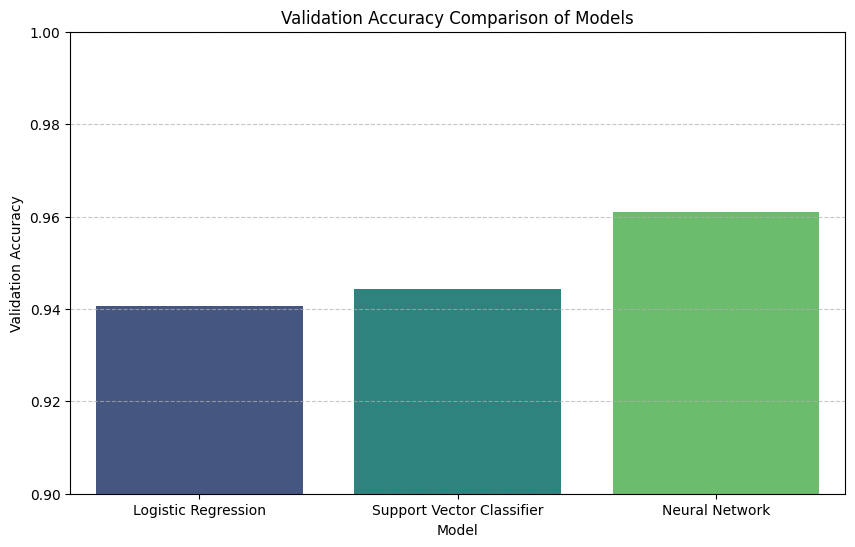

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, palette='viridis')
plt.title('Validation Accuracy Comparison of Models')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0.9, 1.0) # Set y-axis limit to highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()